In [1]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

In [2]:
temps = pd.read_csv('daily-min-temperatures.csv')['Temp'].values.astype('float32')

In [3]:
print(temps)

[20.7 17.9 18.8 ... 13.5 15.7 13. ]


In [4]:
mean = temps[:3000].mean()
std = temps[:3000].std()

print(mean, std)

11.241367 4.11104


In [5]:
temps = (temps - mean) / std
print(temps)

[2.3007884  1.6196953  1.8386179  ... 0.54940665 1.084551   0.4277829 ]


In [6]:
W = 30
Xarr = np.array([temps[i: i+W] for i in range(len(temps) - W)])
Yarr = np.array([temps[i+W] for i in range(len(temps) - W)])

In [7]:
X = torch.tensor(Xarr).unsqueeze(-1)
Y = torch.tensor(Yarr).unsqueeze(-1)

In [8]:
print(X.shape)
print(Y.shape)

torch.Size([3620, 30, 1])
torch.Size([3620, 1])


In [9]:
loader = DataLoader(TensorDataset(X[:3000], Y[:3000]), batch_size=32, shuffle=True)

In [10]:
class Forecaster(nn.Module):
  def __init__(self, hidden=64):
    super().__init__()
    self.lstm = nn.LSTM(1, hidden, batch_first=True)
    self.fc = nn.Linear(hidden, 1)

  def forward(self, x):
    output, _ = self.lstm(x)
    return self.fc(output[:, -1]) # last hidden memory

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [12]:
lstm = Forecaster().to(device)
optimizer = torch.optim.Adam(lstm.parameters(), weight_decay = 0.0001, lr=1e-3)
loss_fn = nn.MSELoss()

In [13]:
for epoch in range(200):
  lstm.train()
  for xb, yb in loader:
    xb, yb = xb.to(device), yb.to(device)
    pred = lstm(xb)
    loss = loss_fn(pred, yb)
    optimizer.zero_grad() # torch uses grad from previous steps, this clears those grads
    loss.backward()
    optimizer.step()

  if epoch % 100 == 0:
    print(f"Epoch {epoch} Loss {loss.item()}")

Epoch 0 Loss 0.4351712465286255
Epoch 100 Loss 0.33859142661094666


In [19]:
# evaluate lstm accuracy
lstm.eval()

with torch.no_grad():
  pred = lstm(X[:3000].to(device)).squeeze() * std + mean # Denormalization
actual = Y[:3000].squeeze() * std + mean # Denormalization

In [21]:
mae = (pred-actual.to(device)).abs().mean()
print(mae)

tensor(1.1767, device='cuda:0')


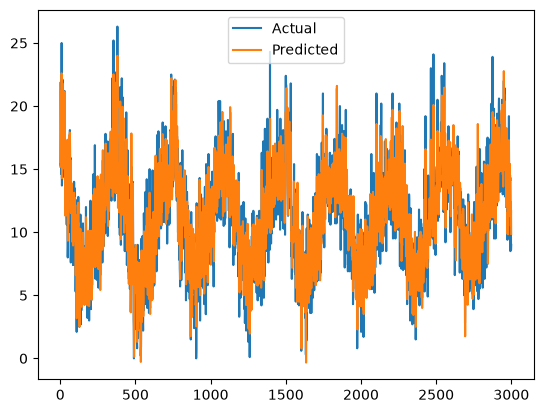

In [23]:
plt.plot(actual.to('cpu').numpy(), label = 'Actual')
plt.plot(pred.to('cpu').numpy(), label='Predicted')
plt.legend()